In [17]:
pip install xgboost

     ---------------------------------------- 72.0/72.0 MB 3.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, average_precision_score
from pyod.utils.data import precision_n_scores
from pyod.models.iforest import IForest
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from pyod.models.xgbod import XGBOD

In [2]:
def evaluate_metrics(y_test, y_pred, y_proba=None, digits=3):
    res = {"Accuracy": round(accuracy_score(y_test, y_pred), digits),
           "Precision": round(precision_score(y_test, y_pred), digits),
           "Recall": round(recall_score(y_test, y_pred), digits),
           "F1": round(f1_score(y_test, y_pred), digits),
           "MCC": round(matthews_corrcoef(y_test, y_pred), ndigits=digits)}
    if y_proba is not None:
        res["AUC_PR"] = round(average_precision_score(y_test, y_proba), digits)
        res["AUC_ROC"] = round(roc_auc_score(y_test, y_proba), digits)
        res["PREC_N_SCORES"] = round(precision_n_scores(y_test, y_proba), digits)
    return res


def set_seed_numpy(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

In [3]:
features = [
    "mean", "var", "std", "len", "duration", "len_weighted", "gaps_squared", "n_peaks",
    "smooth10_n_peaks", "smooth20_n_peaks", "var_div_duration", "var_div_len",
    "diff_peaks", "diff2_peaks", "diff_var", "diff2_var", "kurtosis", "skew",
]
SEED = 2137

In [4]:
df = pd.read_csv("data/dataset.csv", index_col="segment")

#df.plot()

X_train, y_train = df.loc[df.train==1, features], df.loc[df.train==1, "anomaly"]
X_test, y_test = df.loc[df.train==0, features], df.loc[df.train==0, "anomaly"]
X_train_nominal = df.loc[(df.anomaly==0)&(df.train==1), features]

#standardize the data to have a mean of 0 and a standar deviation of 1
#useful when values are in different units, varying length, and sampling frequency
prep = StandardScaler()
X_train_nominal2 = prep.fit_transform(X_train_nominal)
X_train2 = prep.transform(X_train)
X_test2 = prep.transform(X_test)

#print(X_test)
print(X_test2)


[[-0.6027988  -0.60111816 -0.69991101 ... -0.42010039 -0.66621529
  -0.4976555 ]
 [-0.60283501 -0.60111816 -0.699933   ... -0.42010039  1.1129373
  -0.53607548]
 [-0.60281014 -0.60111815 -0.69989178 ... -0.42010039 -0.64887131
  -0.46394204]
 ...
 [-0.60280839 -0.60111816 -0.69995769 ... -0.42010039  0.9883694
  -1.75004747]
 [-0.60272146 -0.60111816 -0.70000922 ... -0.42010039  0.55468953
  -1.50143083]
 [-0.60297508 -0.60111816 -0.69998466 ... -0.42010039 -0.62206268
  -0.42047606]]


In [5]:
set_seed_numpy(SEED)

In [ ]:
# supervised example

In [8]:
import shap

c:\Users\vill799\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
model = AdaBoostClassifier(random_state=SEED)
model.fit(X_train2, y_train)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))

AdaBoostClassifier(random_state=2137) 
 {'Accuracy': 0.936, 'Precision': 0.891, 'Recall': 0.796, 'F1': 0.841, 'MCC': 0.803, 'AUC_PR': 0.926, 'AUC_ROC': 0.966, 'PREC_N_SCORES': 0.841}


In [10]:
#X_test2_df = pd.DataFrame(X_test2, columns=features)
#X_explain = X_test2_df.sample(n=50, random_state=SEED)

X_explain = X_test2[:200]

explainer = shap.KernelExplainer(
    model.decision_function, shap.sample(X_train2, 500, random_state=SEED)
)

shap_values = explainer(X_explain)


Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 200/200 [16:02<00:00,  4.81s/it]


In [11]:
shap.initjs()

C:\Users\vill799\AppData\Local\Temp\ipykernel_40428\131549931.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain)


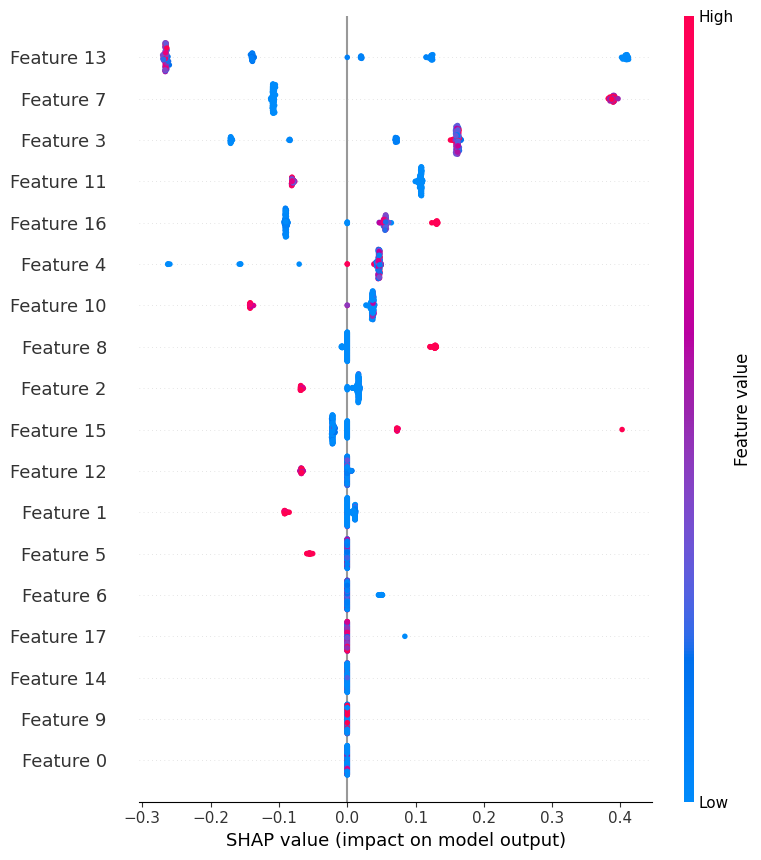

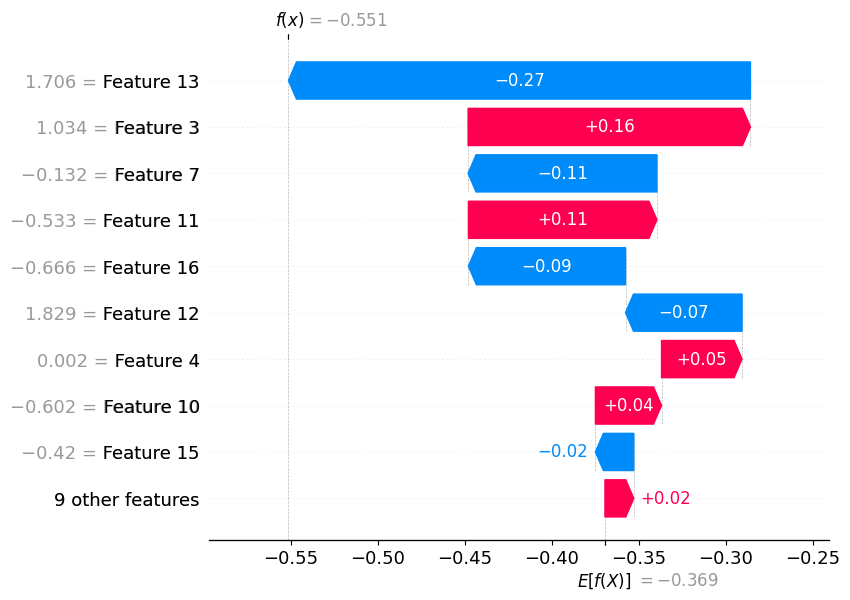

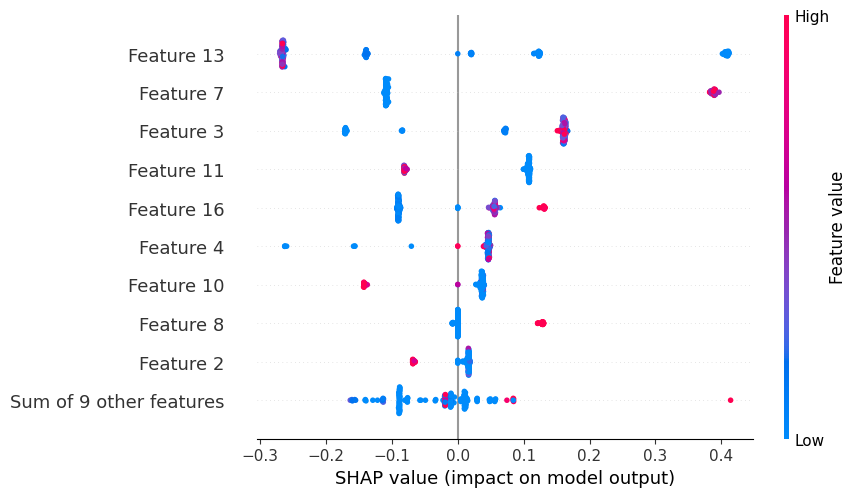

TypeError: object of type 'NoneType' has no len()

In [16]:
shap.summary_plot(shap_values, X_explain)
shap.waterfall_plot(shap_values[0])
#shap.plots.bar(shap_values)
#shap.summary_plot(shap_values, X_test, plot_type="bar")
#shap.dependence_plot("var", shap_values, X_test)
#shap.summary_plot(shap_values, X_test2, plot_type="dot")

shap.plots.beeswarm(shap_values)
#shap.plots.waterfall(shap_values[7])
shap.plots.force(shap_values[0])
shap.plots.scatter(shap_values[0], color=shap_values)



In [ ]:
# unsupervised example

In [ ]:
#model = IForest(random_state=SEED)
#model.fit(X_train2)

#y_predicted = model.predict(X_test2)
#y_predicted_score = model.decision_function(X_test2)

#print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))

In [24]:
model = IForest(random_state=SEED, contamination=.2)
model.fit(X_train2)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))

IForest(behaviour='old', bootstrap=False, contamination=0.2, max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=2137,
    verbose=0) 
 {'Accuracy': 0.696, 'Precision': 0.289, 'Recall': 0.292, 'F1': 0.291, 'MCC': 0.097, 'AUC_PR': 0.352, 'AUC_ROC': 0.627, 'PREC_N_SCORES': 0.292}


In [ ]:
import shap

C:\Users\vill799\AppData\Local\Temp\ipykernel_41200\1777424206.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test2)


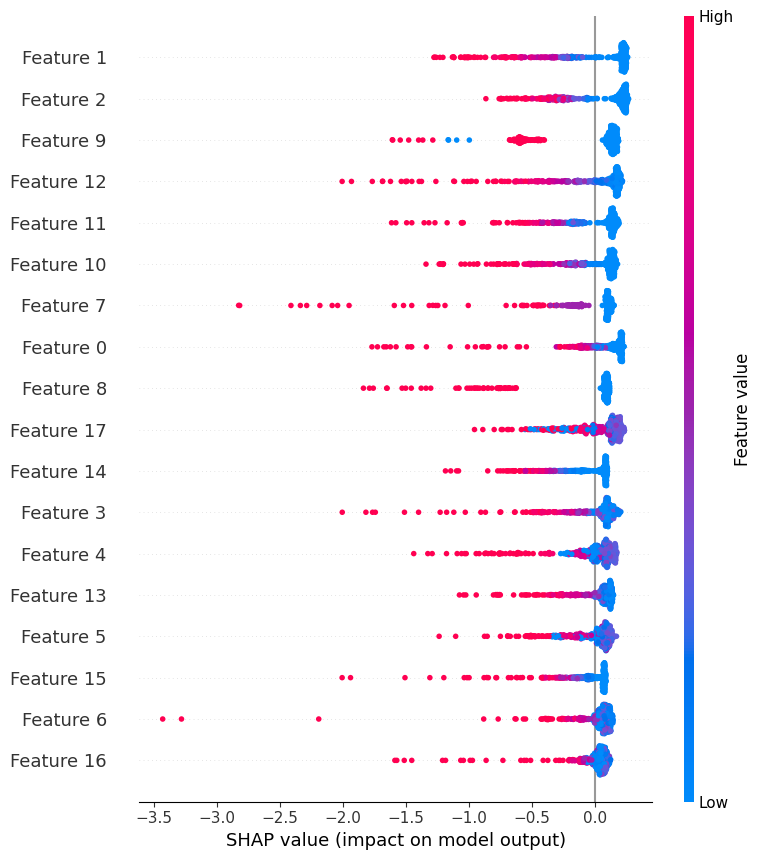

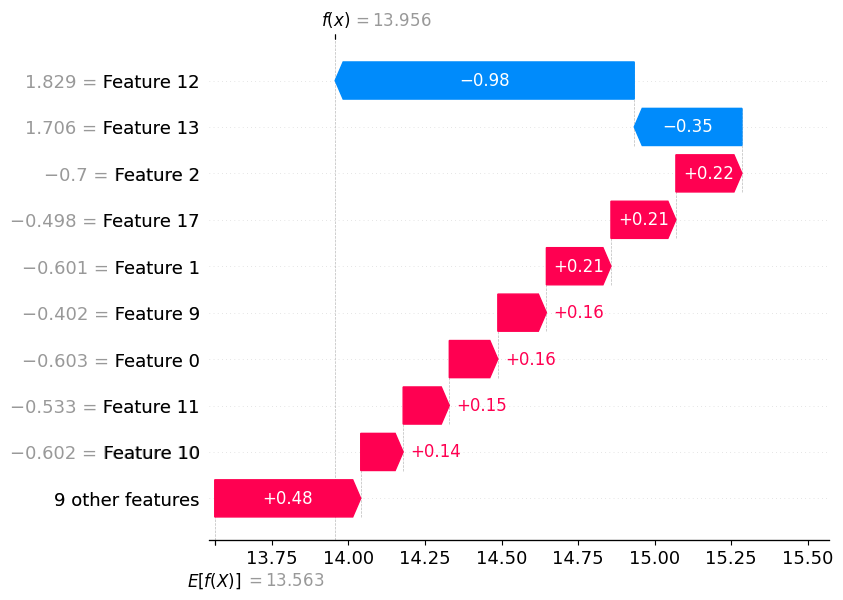

In [27]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test2)

shap.summary_plot(shap_values, X_test2)
shap.waterfall_plot(shap_values[0])
#shap.plots.bar(shap_values)

shap.plots.force(shap_values)



In [10]:
model = RandomForestClassifier(random_state=SEED)
model.fit(X_train2,y_train)

y_predicted = model.predict(X_test2)
y_predicted_score = model.predict_proba(X_test2)[:, 1]

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))
#y_predicted


RandomForestClassifier(random_state=2137) 
 {'Accuracy': 0.97, 'Precision': 0.971, 'Recall': 0.885, 'F1': 0.926, 'MCC': 0.909, 'AUC_PR': 0.97, 'AUC_ROC': 0.988, 'PREC_N_SCORES': 0.894}


C:\Users\vill799\AppData\Local\Temp\ipykernel_41620\3272137720.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test2)
c:\Users\vill799\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\vill799\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this 

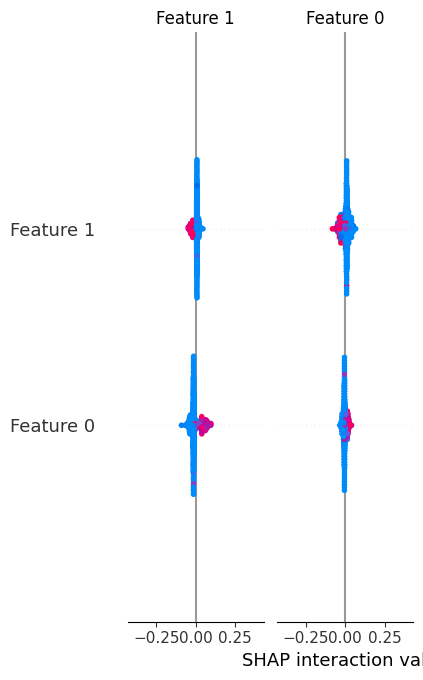

In [12]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test2, check_additivity=False)


shap.summary_plot(shap_values, X_test2)
#shap.plots.bar(shap_values)

In [26]:
model = XGBOD(random_state=SEED, contamination=.2)
model.fit(X_train2, y_train)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))

c:\Users\vill799\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyod\models\base.py:554: UserWarning: y should not be presented in unsupervised learning.
  warnings.warn(
c:\Users\vill799\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:57:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "contamination", "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBOD(base_score=0.5, booster='gbtree', colsample_bylevel=1,
   colsample_bytree=1,
   estimator_list=[KNN(algorithm='auto', contamination=0.1, leaf_size=30, method='largest',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=1, p=2,
  radius=1.0), LOF(algorithm='auto', contamination=0.1, leaf_size=30, metric='minkowski',
  metric_params=None, n_jobs=1, n_neighbors=1, no...features=1.0,
    max_samples='auto', n_estimators=200, n_jobs=1, random_state=2137,
    verbose=0)],
   gamma=0, learning_rate=0.1, max_delta_step=0, max_depth=3,
   min_child_weight=1, n_estimators=100, n_jobs=1, nthread=None,
   objective='binary:logistic', random_state=2137, reg_alpha=0,
   reg_lambda=1, scale_pos_weight=1, silent=True,
   standardization_flag_list=[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, True, True, True, False, False, False, False

In [32]:
X_explain = X_test2[:50]

explainer = shap.Explainer(
    model.decision_function,
    shap.sample(X_train2, 100, random_state=SEED)
)

shap_values = explainer(X_explain)




PermutationExplainer explainer: 51it [1:29:24, 107.29s/it]                          


C:\Users\vill799\AppData\Local\Temp\ipykernel_35912\2186075552.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain)


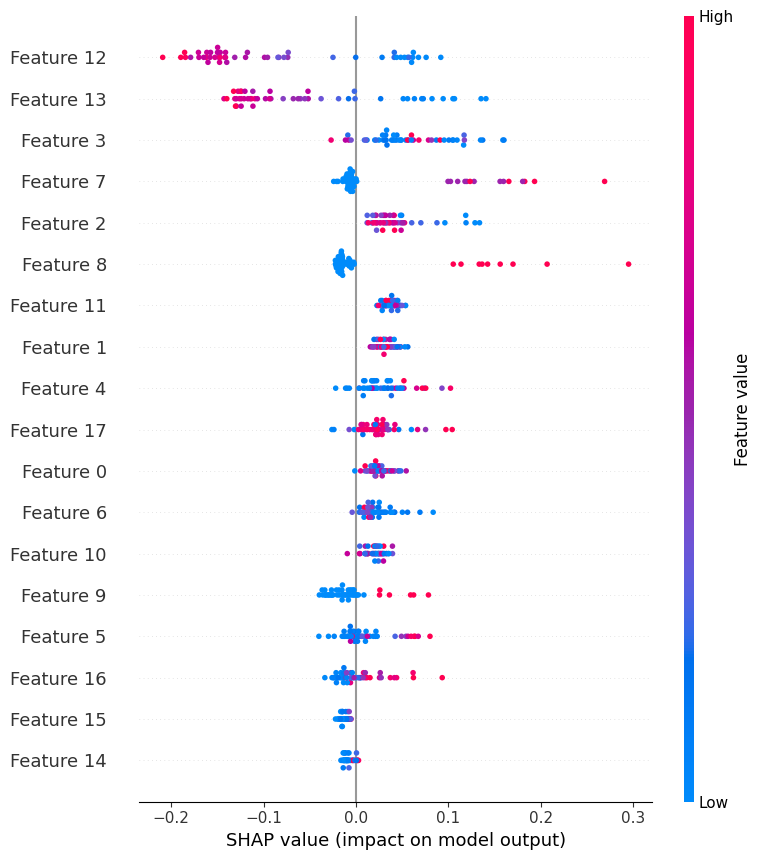

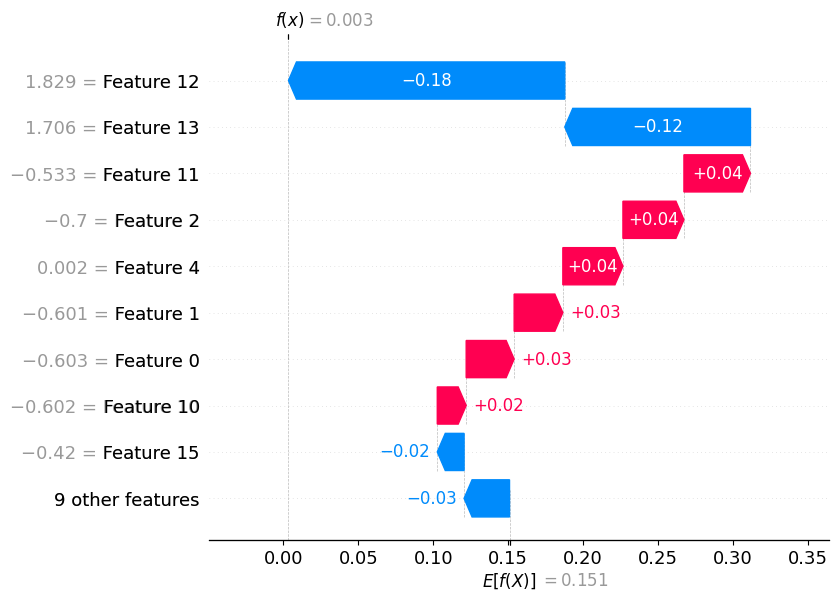

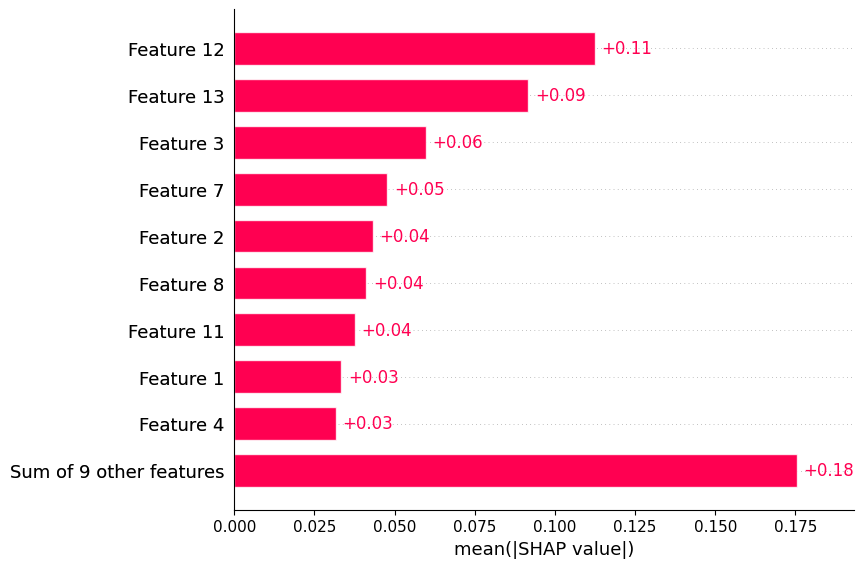

In [39]:
np.shape(shap_values)
shap.summary_plot(shap_values, X_explain)
shap.waterfall_plot(shap_values[0])
shap.plots.bar(shap_values)

shap.plots.force(shap_values)
